## Table of Contents
- How machine learns: A 14 stage simulator
- Linear Regression
- Ridge and Lasso Regression
- Full code example
- Linear Regression Math
- Notation Confusion



<div style="background:#0f0e0c;color:#e8c547;padding:32px 40px;border-radius:12px;margin-bottom:8px">
<h1 style="font-size:2.2em;margin:0 0 8px">How Machines Learn</h1>
<p style="color:#9a9488;font-size:1.1em;margin:0">A visual, interactive guide to Linear Regression & Gradient Descent</p>
</div>

---
This notebook walks you through **14 interactive stages** — from understanding what a line is, all the way to building a working ML model using gradient descent.  
**Run each cell** and interact with the sliders. Use `Shift+Enter` to run a cell.

> 💡 **Before starting:** Run the setup cell below first!

In [2]:
# @title
# ── SETUP — Run this first! ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import warnings
warnings.filterwarnings('ignore')
import matplotlib
matplotlib.pyplot.switch_backend('inline')

# ── Colour palette ──────────────────────────────────────────────────────
BG      = '#0f0e0c'
SURFACE = '#1a1916'
S2      = '#222018'
TEXT    = '#f0ece3'
TEXT2   = '#9a9488'
ACCENT  = '#e8c547'
BLUE    = '#5b9cf6'
RED     = '#f05c5c'
GREEN   = '#4ec994'
PURPLE  = '#a78bfa'

def style_ax(ax, xlabel='', ylabel='', title=''):
    ax.set_facecolor(SURFACE)
    ax.figure.patch.set_facecolor(BG)
    for spine in ax.spines.values():
        spine.set_color('#333')
    ax.tick_params(colors=TEXT2, labelsize=9)
    ax.xaxis.label.set_color(TEXT2)
    ax.yaxis.label.set_color(TEXT2)
    ax.grid(True, color='#2a2825', linewidth=0.5, zorder=0)
    if xlabel: ax.set_xlabel(xlabel, color=TEXT2)
    if ylabel: ax.set_ylabel(ylabel, color=TEXT2)
    if title:  ax.set_title(title, color=TEXT, fontsize=13, fontweight='bold', pad=10)

# ── Student data ────────────────────────────────────────────────────────
# names  = ['Rahim','Fatima','Arif','Nusrat','Karim','Sabrina','Hasan','Priya','Zara','Imran']
# hours  = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)
# marks  = np.array([35,42,50,58,63,72,78,84,89,95], dtype=float)
names = [
        "Arif", "Nusrat", "Sohan", "Mim", "Tanvir", "Jannat",
        "Riad", "Tania", "Shuvo", "Priya", "Sabbir", "Oishi",
        "Fahim", "Nabila", "Rakib", "Mehjabin", "Imran", "Farzana",
        "Sakib", "Brishti", "Hasan", "Shayla", "Nayeem", "Anika",
        "Shakil", "Moumita", "Zubair", "Lamia", "Adnan", "Sadia"
    ]
hours =  np.array([
        1, 2, 1.5, 3, 2.5, 4,
        3.5, 5, 4.5, 6, 5.5, 7,
        6.5, 8, 7.5, 9, 8.5, 10,
        9.5, 2, 3, 4, 5, 6,
        7, 8, 9, 10, 2.5, 4.5
    ])

marks = np.array([
        35, 40, 38, 50, 48, 60,
        58, 70, 68, 78, 75, 85,
        82, 90, 88, 95, 92, 98,
        96, 42, 52, 61, 72, 80,
        86, 91, 94, 99, 47, 67
    ])


# ── True best-fit (least squares) ───────────────────────────────────────
TRUE_M = np.cov(hours, marks)[0,1] / np.var(hours)
TRUE_C = marks.mean() - TRUE_M * hours.mean()

def compute_loss(m, c):
    preds = m * hours + c
    return np.mean((marks - preds) ** 2)

def compute_grad_m(m, c):
    preds = m * hours + c
    return np.mean(2 * (preds - marks) * hours)

def compute_grad_c(m, c):
    preds = m * hours + c
    return np.mean(2 * (preds - marks))

print('✅  Setup complete! True best-fit: m =', round(TRUE_M, 3), '  c =', round(TRUE_C, 3))
display(HTML('<p style="color:#4ec994;font-size:14px">Now scroll down and run each stage cell.</p>'))

✅  Setup complete! True best-fit: m = 7.604   c = 29.287


---
## 📐 Part 1 — Understanding Lines

---
### Stage 1 · What is a line?

Every straight line has two properties:
- **Slope (m)** — how steep the line is. Positive = goes up, negative = goes down.
- **Intercept (c)** — where the line crosses the vertical axis (when x = 0).

The equation is: &nbsp; <span style="color:#e8c547">**y = m·x + c**</span>

Use the sliders below to explore.

---
### Stage 2 · Meet the data — study hours vs marks

Here are **10 students**. Each point shows how many hours they studied and what marks they got.  
Do students who study more tend to score higher?

In [3]:
# @title
# ── Stage 1: Interactive line explorer ─────────────────────────────────
m_slider = widgets.FloatSlider(value=1.0, min=-3.0, max=3.0, step=0.1,
    description='Slope (m)', style={'description_width':'100px'},
    layout=widgets.Layout(width='420px'))
c_slider = widgets.FloatSlider(value=0.0, min=-5.0, max=10.0, step=0.5,
    description='Intercept (c)', style={'description_width':'100px'},
    layout=widgets.Layout(width='420px'))

out1 = widgets.Output()

def draw_line_explorer(m, c):
    with out1:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(7, 4))
        x = np.linspace(-5, 5, 200)
        y = m * x + c
        ax.axhline(0, color='#333', linewidth=0.8)
        ax.axvline(0, color='#333', linewidth=0.8)
        ax.plot(x, y, color=ACCENT, linewidth=2.5, label=f'y = {m:.1f}x + {c:.1f}')
        # intercept dot
        ax.scatter([0], [c], color=PURPLE, s=80, zorder=5, label=f'Intercept = {c:.1f}')
        style_ax(ax, xlabel='x', ylabel='y')
        ax.set_xlim(-5, 5)
        ax.set_ylim(-10, 14)
        ax.legend(facecolor=S2, labelcolor=TEXT, fontsize=10)
        slope_desc = 'going UP ↗' if m > 0 else ('going DOWN ↘' if m < 0 else 'FLAT →')
        ax.set_title(f'Slope = {m:.1f}  ({slope_desc})    Intercept = {c:.1f}',
                     color=TEXT, fontsize=11, pad=10)
        plt.tight_layout()
        plt.show()

widgets.interactive_output(draw_line_explorer, {'m': m_slider, 'c': c_slider})
display(widgets.VBox([m_slider, c_slider, out1]))

In [18]:
# @title
# ── Stage 2: Scatter plot reveal ───────────────────────────────────────
n_slider = widgets.IntSlider(value=0, min=0, max=30, step=1,
    description='Students shown:', style={'description_width':'130px'},
    layout=widgets.Layout(width='440px'))
show_all_btn = widgets.Button(description='Show all', button_style='info',
    layout=widgets.Layout(width='120px'))
out2 = widgets.Output()

def draw_scatter(n):
    with out2:
        clear_output(wait=True)
        fig, (ax_plot, ax_table) = plt.subplots(1, 2, figsize=(15, 6),
                                                  gridspec_kw={'width_ratios':[2,1]})
        if n > 0:
            ax_plot.scatter(hours[:n], marks[:n], color=BLUE, s=90, zorder=5,
                            edgecolors='white', linewidths=0.5)
            for i in range(n):
                ax_plot.annotate(names[i], (hours[i], marks[i]),
                                 textcoords='offset points', xytext=(6,4),
                                 color=TEXT2, fontsize=8)
        ax_plot.set_xlim(0, 11); ax_plot.set_ylim(25, 105)
        style_ax(ax_plot, xlabel='Study hours', ylabel='Marks',
                 title=f'Student data ({n} / {len(hours)} shown)')
        # table
        ax_table.set_facecolor(SURFACE)
        ax_table.figure.patch.set_facecolor(BG)
        ax_table.axis('off')
        if n > 0:
            rows = [[names[i], f'{int(hours[i])}h', f'{int(marks[i])}'] for i in range(n)]
            col_labels = ['Name', 'Hours', 'Marks']
            tbl = ax_table.table(cellText=rows, colLabels=col_labels,
                                  loc='center', cellLoc='center')
            tbl.auto_set_font_size(False); tbl.set_fontsize(9)
            for (r, col), cell in tbl.get_celld().items():
                cell.set_facecolor(S2 if r == 0 else SURFACE)
                cell.set_text_props(color=TEXT if r == 0 else TEXT2)
                cell.set_edgecolor('#333')
        plt.tight_layout(); plt.show()

def on_show_all(b): n_slider.value = 30
show_all_btn.on_click(on_show_all)
widgets.interactive_output(draw_scatter, {'n': n_slider})
display(widgets.VBox([widgets.HBox([n_slider, show_all_btn]), out2]))

---
### Stage 3 · Why does ML need a line?

> 🤖 A computer doesn't understand words like *"studied hard"* or *"did well"*. It only understands **numbers**.

So we need a **mathematical rule** that connects study hours (input) to marks (output). That rule is a **line**.

| Symbol | Meaning | Example |
|--------|---------|----------|
| **x** | Input / Feature | Study hours |
| **y** | Output / Target | Marks |
| **m** | Slope | How much marks increase per hour |
| **c** | Intercept | Baseline mark at 0 hours |

Once we have the line: *"If a student studies 7 hours, what mark will they get?"* — the line gives us an answer automatically.

- **Line Equation:**  &nbsp; `y = mx + c`
- **The model:** &nbsp; `marks = m × hours + c`
- **x** = hours (input/feature)
- **y** = marks (output/target)


---
### Stage 4 · y = mx + c — the equation in action

Each part of the equation has a job. Move the slider to pick study hours and watch the model compute a prediction.

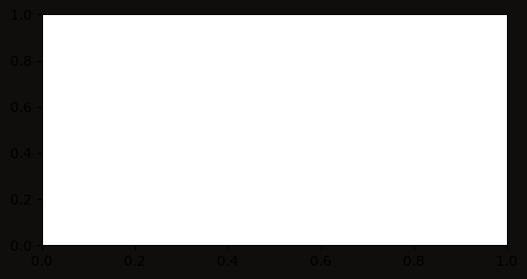

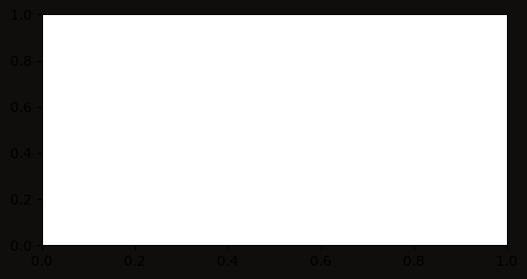

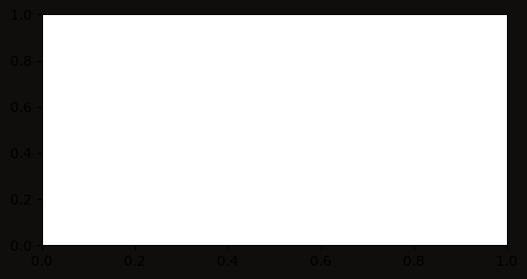

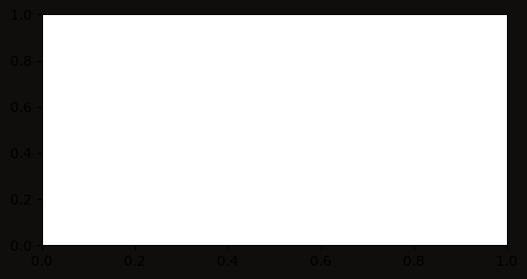

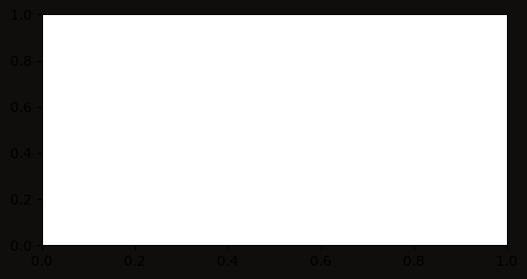

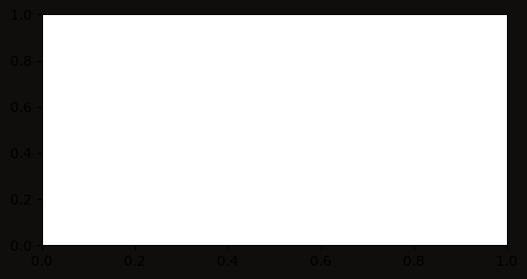

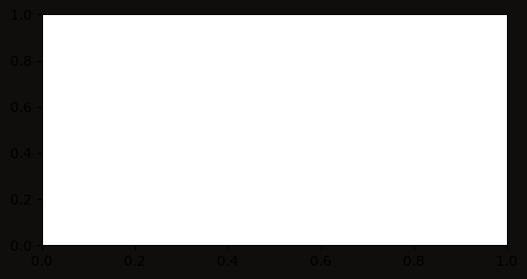

In [17]:
# @title
# ── Stage 4: Equation explorer ──────────────────────────────────────────
S4_M, S4_C = 8.0, 20.0

x_slider = widgets.FloatSlider(
    value=5, min=1, max=10, step=0.5,
    description='Study hours (x):',
    style={'description_width': '140px'},
    layout=widgets.Layout(width='460px')
)
out4 = widgets.Output()

def draw_eq_explorer(x_val):
    pred = S4_M * x_val + S4_C

    fig, ax = plt.subplots(figsize=(6, 3))
    fig.patch.set_facecolor(BG)

    x_line = np.linspace(0, 11, 200)
    ax.scatter(hours, marks, color=BLUE, s=80, zorder=5,
               edgecolors='white', linewidths=0.5, label='Students')
    ax.plot(x_line, S4_M * x_line + S4_C, color=ACCENT, linewidth=2, label='Our line')
    ax.axvline(x=x_val, color=BLUE, linewidth=1, linestyle='--', alpha=0.6)
    ax.scatter([x_val], [pred], color=GREEN, s=130, zorder=8,
               edgecolors='white', linewidths=1)
    ax.annotate(f'Predicted: {pred:.0f}', (x_val, pred),
                textcoords='offset points', xytext=(10, -14),
                color=GREEN, fontsize=10, fontweight='bold')
    ax.set_xlim(0, 11); ax.set_ylim(20, 115)
    style_ax(ax, xlabel='Study hours', ylabel='Marks',
             title='Predicting marks from study hours')
    ax.legend(facecolor=S2, labelcolor=TEXT, fontsize=9)
    plt.tight_layout()

    # Convert figure to image bytes — display as <img>, never flickers
    import io, base64
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=110, bbox_inches='tight',
                facecolor=BG)
    plt.close(fig)  # free memory
    buf.seek(0)
    img_b64 = base64.b64encode(buf.read()).decode('utf-8')

    with out4:
        clear_output(wait=True)
        display(HTML(f"""
        <div style="background:#1a1916;border:1px solid #333;border-radius:10px;width:66%;
                    padding:16px 24px;margin:4px 0 10px;font-family:monospace;font-size:16px">
          <span style="color:#4ec994">marks</span>
          <span style="color:#9a9488"> = </span>
          <span style="color:#e8c547">{S4_M}</span>
          <span style="color:#9a9488"> &times; </span>
          <span style="color:#5b9cf6">{x_val:.1f}</span>
          <span style="color:#9a9488"> + </span>
          <span style="color:#a78bfa">{S4_C}</span>
          <span style="color:#9a9488"> = </span>
          <span style="color:#4ec994;font-size:22px"><b>{pred:.0f}</b></span>
        </div>
        <img src="data:image/png;base64,{img_b64}"
             style="width:70%;border-radius:8px;display:block"/>
        """))

widgets.interactive_output(draw_eq_explorer, {'x_val': x_slider})
display(widgets.VBox([x_slider, out4]))

---
## 🎯 Part 2 — Finding the Best Line

---
### Stage 5 · Guess the line yourself

Before we let the computer do it — **try fitting the line manually**. Adjust slope and intercept until the line passes through as many dots as possible. It's harder than it looks!

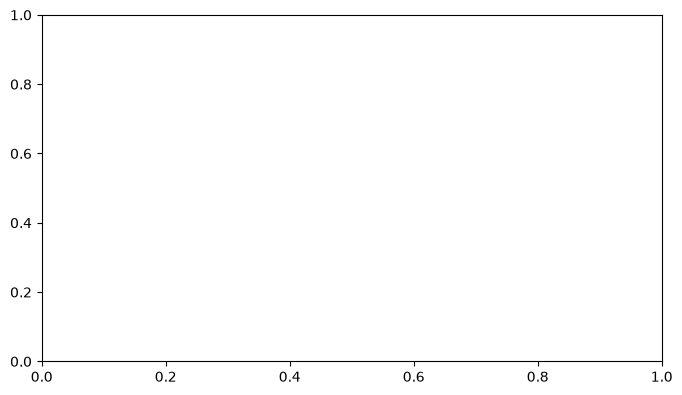

In [6]:
# @title
# ── Stage 5: Manual line fitting ────────────────────────────────────────
s5_m = widgets.FloatSlider(value=8, min=0, max=20, step=0.5,
    description='Slope (m):', style={'description_width':'100px'},
    layout=widgets.Layout(width='440px'))
s5_c = widgets.FloatSlider(value=20, min=-10, max=60, step=1,
    description='Intercept (c):', style={'description_width':'100px'},
    layout=widgets.Layout(width='440px'))
out5 = widgets.Output()

def draw_manual_fit(m, c):
    loss = compute_loss(m, c)
    best_loss = compute_loss(TRUE_M, TRUE_C)
    with out5:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(8, 4.5))
        ax.scatter(hours, marks, color=BLUE, s=90, zorder=5,
                   edgecolors='white', linewidths=0.5, label='Students')
        x_line = np.linspace(0, 11, 200)
        ax.plot(x_line, m * x_line + c, color=ACCENT, linewidth=2.5,
                label=f'Your line: y = {m:.1f}x + {c:.0f}')
        ax.plot(x_line, TRUE_M * x_line + TRUE_C, color=GREEN, linewidth=1.5,
                linestyle='--', alpha=0.5, label='Best possible (hidden in real ML!)')
        ax.set_xlim(0, 11); ax.set_ylim(20, 115)
        style_ax(ax, xlabel='Study hours', ylabel='Marks')
        quality = '🟢 Excellent!' if loss < best_loss*1.5 else ('🟡 Getting there' if loss < best_loss*3 else '🔴 Quite far off')
        ax.set_title(f'Your Loss (MSE) = {loss:.1f}   |   Best possible = {best_loss:.1f}   {quality}',
                     color=TEXT, fontsize=10, pad=10)
        ax.legend(facecolor=S2, labelcolor=TEXT, fontsize=9)
        plt.tight_layout(); plt.show()

widgets.interactive_output(draw_manual_fit, {'m': s5_m, 'c': s5_c})
display(widgets.VBox([s5_m, s5_c, out5]))

---
### Stage 6 · What makes a line wrong? — Residuals

The **gap** between what the line predicts and the actual mark is called a **residual**.

> **Residual = Actual − Predicted**

- If a student scored **75** and your line predicts **60** → residual = **+15** (predicted too low)
- If your line predicts **80** → residual = **−5** (predicted too high)

Move the sliders and watch the red dashed residual lines grow and shrink.

In [7]:
# @title
# ── Stage 6: Residuals ──────────────────────────────────────────────────
s6_m = widgets.FloatSlider(value=8, min=0, max=20, step=0.5,
    description='Slope (m):', style={'description_width':'100px'},
    layout=widgets.Layout(width='440px'))
s6_c = widgets.FloatSlider(value=20, min=-10, max=60, step=1,
    description='Intercept (c):', style={'description_width':'100px'},
    layout=widgets.Layout(width='440px'))
out6 = widgets.Output()

def draw_residuals(m, c):
    preds = m * hours + c
    residuals = marks - preds
    with out6:
        clear_output(wait=True)
        fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 4.5),
                                       gridspec_kw={'width_ratios':[2,1]})
        # Scatter with residuals
        x_line = np.linspace(0, 11, 200)
        ax.plot(x_line, m*x_line+c, color=ACCENT, linewidth=2)
        for i in range(len(hours)):
            ax.plot([hours[i], hours[i]], [marks[i], preds[i]],
                    color=RED, linewidth=1.5, linestyle='--', alpha=0.8)
        ax.scatter(hours, marks, color=BLUE, s=90, zorder=5,
                   edgecolors='white', linewidths=0.5)
        ax.set_xlim(0, 11); ax.set_ylim(20, 115)
        style_ax(ax, xlabel='Study hours', ylabel='Marks', title='Residuals (red dashed = prediction gap)')
        # Residual bar chart
        colors = [GREEN if r >= 0 else RED for r in residuals]
        ax2.barh(names, residuals, color=colors, alpha=0.8, edgecolor='#333')
        ax2.axvline(0, color=TEXT2, linewidth=1)
        ax2.set_facecolor(SURFACE); ax2.figure.patch.set_facecolor(BG)
        ax2.tick_params(colors=TEXT2, labelsize=9)
        ax2.set_title(f'Residuals per student\nTotal |gaps| = {np.sum(np.abs(residuals)):.1f}',
                      color=TEXT, fontsize=10)
        for spine in ax2.spines.values(): spine.set_color('#333')
        plt.tight_layout(); plt.show()

widgets.interactive_output(draw_residuals, {'m': s6_m, 'c': s6_c})
display(widgets.VBox([s6_m, s6_c, out6]))

---
### Stage 7 · Why do we square the errors?

**The problem:** if you just add up all residuals, positive and negative errors cancel each other out — making a bad line look perfect!

**The fix:** square each error → all values become positive → bad lines get exposed.

Run the cell below to see two very different lines that have the **same sum of raw errors**, but very different **sum of squared errors**.

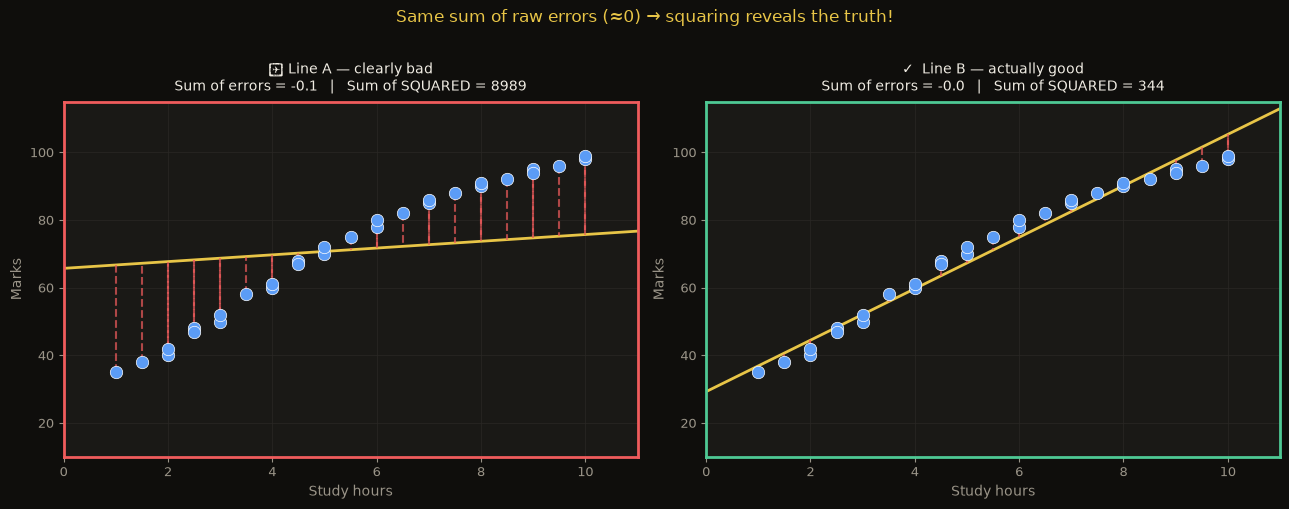

In [8]:
# @title
# ── Stage 7: Why square? ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Line A: deliberately bad line — wrong slope, but crafted so raw errors cancel to 0
# Line B: the true best-fit line
lines = [
    (1.0, 65.72, '❌ Line A — clearly bad', RED),
    (TRUE_M, TRUE_C, '✓  Line B — actually good', GREEN)
]

for ax, (m, c, title, color) in zip(axes, lines):
    preds  = m * hours + c
    resid  = marks - preds
    sum_r  = resid.sum()
    sum_sq = (resid**2).sum()
    x_line = np.linspace(0, 11, 200)
    ax.plot(x_line, m*x_line+c, color=ACCENT, linewidth=2)
    for i in range(len(hours)):
        ax.plot([hours[i], hours[i]], [marks[i], preds[i]],
                color=RED, linewidth=1.5, linestyle='--', alpha=0.7)
    ax.scatter(hours, marks, color=BLUE, s=80, zorder=5,
               edgecolors='white', linewidths=0.5)
    ax.set_xlim(0, 11); ax.set_ylim(10, 115)
    style_ax(ax, xlabel='Study hours', ylabel='Marks')
    ax.set_title(f'{title}\nSum of errors = {sum_r:.1f}   |   Sum of SQUARED = {sum_sq:.0f}',
                 color=TEXT, fontsize=10, pad=8)
    for spine in ax.spines.values(): spine.set_linewidth(2); spine.set_color(color)

plt.suptitle('Same sum of raw errors (≈0) → squaring reveals the truth!', color=ACCENT, fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

display(HTML(f"""
<div style="background:#1a1916;border:1px solid #e8c54766;border-radius:10px;padding:14px 20px;margin-top:8px">
<b style="color:#e8c547">Key insight:</b>
<span style="color:#9a9488"> Both lines have raw errors that sum to <b style="color:#f0ece3">≈ 0</b> — as if they made no mistakes at all!
But Line A's squared errors (<b style="color:#f05c5c">8,989</b>) are <b style="color:#f05c5c">~26×</b> worse than Line B's (<b style="color:#4ec994">344</b>).
This is exactly why we use <b style="color:#e8c547">Mean Squared Error (MSE)</b> as our loss function insted of <b style="color:#e8c547"> Mean Absolute Error (MAE) </b></span>
</div>
"""))

---
### Stage 8 · Loss — a single score for "wrongness"

We call the average squared error the **loss** (specifically **MSE — Mean Squared Error**).

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (\text{actual}_i - \text{predicted}_i)^2$$

One number. **Lower = better.** Our entire goal: make this number as small as possible.

In [9]:
# @title
# ── Stage 8: Loss meter ─────────────────────────────────────────────────
s8_m = widgets.FloatSlider(value=5, min=0, max=20, step=0.5,
    description='Slope (m):', style={'description_width':'100px'},
    layout=widgets.Layout(width='440px'))
s8_c = widgets.FloatSlider(value=40, min=-10, max=60, step=1,
    description='Intercept (c):', style={'description_width':'100px'},
    layout=widgets.Layout(width='440px'))
out8 = widgets.Output()

def draw_loss_meter(m, c):
    loss = compute_loss(m, c)
    best = compute_loss(TRUE_M, TRUE_C)
    pct  = min(1.0, max(0.02, (loss - best) / 1800))
    with out8:
        clear_output(wait=True)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5),
                                        gridspec_kw={'width_ratios':[2,1]})
        # Scatter + residuals
        preds = m * hours + c
        x_line = np.linspace(0, 11, 200)
        ax1.plot(x_line, m*x_line+c, color=ACCENT, linewidth=2)
        for i in range(len(hours)):
            ax1.plot([hours[i],hours[i]], [marks[i],preds[i]],
                     color=RED, linewidth=1.5, linestyle='--', alpha=0.7)
        ax1.scatter(hours, marks, color=BLUE, s=80, zorder=5,
                    edgecolors='white', linewidths=0.5)
        ax1.set_xlim(0, 11); ax1.set_ylim(20, 115)
        style_ax(ax1, xlabel='Study hours', ylabel='Marks', title='Residuals')
        # Loss gauge
        ax2.set_facecolor(SURFACE); ax2.figure.patch.set_facecolor(BG)
        ax2.set_xlim(0, 1); ax2.set_ylim(0, 3); ax2.axis('off')
        # gradient bar
        grad = np.linspace(0, 1, 300)
        bar_h = 0.6
        for i, g in enumerate(grad):
            c_bar = plt.cm.RdYlGn(1 - g)
            ax2.barh(1.5, 1/300, left=i/300, height=bar_h, color=c_bar, edgecolor='none')
        # needle
        ax2.axvline(pct, ymin=0.35, ymax=0.65, color='white', linewidth=3)
        ax2.text(0.5, 2.4, f'Loss (MSE)', ha='center', color=TEXT2, fontsize=10)
        ax2.text(pct, 2.0, f'{loss:.0f}', ha='center', color=ACCENT, fontsize=18, fontweight='bold')
        ax2.text(0.01, 1.1, 'perfect\n(0)', ha='left', color=GREEN, fontsize=8)
        ax2.text(0.99, 1.1, 'terrible', ha='right', color=RED, fontsize=8)
        ax2.text(0.5, 0.6, f'Best possible: {best:.1f}', ha='center', color=GREEN, fontsize=9)
        plt.tight_layout(); plt.show()

widgets.interactive_output(draw_loss_meter, {'m': s8_m, 'c': s8_c})
display(widgets.VBox([s8_m, s8_c, out8]))

---
### Stage 9 · The loss has a shape — a bowl 🥣

If we try **every possible slope** and plot its loss, we get a **U-shaped bowl**.  
The very **bottom of the bowl** is the best slope. Drag the slider to explore it.

In [10]:
# @title
# ── Stage 9: Loss landscape / bowl ─────────────────────────────────────
plt.switch_backend('inline')

m_range   = np.linspace(-5, 20, 400)
loss_vals = [compute_loss(m, TRUE_C) for m in m_range]

s9_m = widgets.FloatSlider(value=5, min=-5, max=20, step=0.1,
    description='Try slope (m):', style={'description_width':'130px'},
    layout=widgets.Layout(width='480px'))
out9 = widgets.Output()

def draw_bowl(m):
    cur_loss  = compute_loss(m, TRUE_C)
    best_loss = compute_loss(TRUE_M, TRUE_C)
    grad      = compute_grad_m(m, TRUE_C)

    with out9:
        clear_output(wait=True)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

        # ── Bowl ──────────────────────────────────────────────────────
        ax1.plot(m_range, loss_vals, color=BLUE, linewidth=2.5)
        ax1.scatter([m], [cur_loss], color=ACCENT, s=150, zorder=6,
                    label=f'Your m={m:.1f} → loss={cur_loss:.0f}')
        ax1.scatter([TRUE_M], [best_loss], color=GREEN, s=120, zorder=6,
                    marker='*', label=f'Best m={TRUE_M:.2f} → loss={best_loss:.0f}')
        # tangent
        t = np.linspace(m-2, m+2, 50)
        ax1.plot(t, cur_loss + grad*(t-m), color=PURPLE, linewidth=1.5,
                 linestyle='--', alpha=0.8, label='Tangent (gradient)')

        # ── Centre axes on (0, 0) ─────────────────────────────────────
        ax1.spines['left'].set_position('zero')    # y-axis at x=0
        ax1.spines['bottom'].set_position('zero')  # x-axis at y=0
        ax1.spines['right'].set_visible(False)
        ax1.spines['top'].set_visible(False)
        ax1.spines['left'].set_color(TEXT2)
        ax1.spines['bottom'].set_color(TEXT2)
        ax1.set_facecolor(SURFACE)
        ax1.figure.patch.set_facecolor(BG)
        ax1.tick_params(colors=TEXT2, labelsize=9)
        ax1.xaxis.label.set_color(TEXT2)
        ax1.yaxis.label.set_color(TEXT2)
        ax1.grid(True, color='#2a2825', linewidth=0.5)

        ax1.set_xlim(-5, 20)
        ax1.set_xlabel('Slope (m)', color=TEXT2, labelpad=10)
        ax1.set_ylabel('Loss (MSE)', color=TEXT2, labelpad=10)
        ax1.set_title('The Loss Bowl', color=TEXT, fontsize=13, pad=10)
        ax1.legend(facecolor=S2, labelcolor=TEXT, fontsize=9)

        # ── Scatter with current line ──────────────────────────────────
        x_line = np.linspace(0, 11, 200)
        ax2.plot(x_line, m*x_line+TRUE_C, color=ACCENT, linewidth=2,
                 label=f'm={m:.1f}')
        ax2.plot(x_line, TRUE_M*x_line+TRUE_C, color=GREEN, linewidth=1.5,
                 linestyle='--', alpha=0.6, label='Best fit')
        ax2.scatter(hours, marks, color=BLUE, s=80, zorder=5,
                    edgecolors='white', linewidths=0.5)
        ax2.set_xlim(0, 11); ax2.set_ylim(20, 115)
        style_ax(ax2, xlabel='Study hours', ylabel='Marks',
                 title='Corresponding line on data')
        ax2.legend(facecolor=S2, labelcolor=TEXT, fontsize=9)

        direction = ('← decrease m' if grad > 0.5
                     else ('increase m →' if grad < -0.5
                     else '✅ near the minimum!'))
        plt.suptitle(f'Gradient = {grad:.1f}   →   {direction}',
                     color=PURPLE, fontsize=11, y=1.01)
        plt.tight_layout()
        plt.show()

interactive_out9 = widgets.interactive_output(draw_bowl, {'m': s9_m})
display(widgets.VBox([s9_m, out9]))

---
## ⛰️ Part 3 — Gradient Descent

---
### Stage 10 · Why "Descent"?

**Descent** means *going downhill*. Think of the loss curve as a hilly landscape.

- The **hill** = the loss curve
- The **valley** = the slope value (m) that gives the **lowest loss** = best line
- Our strategy: always take a small step **downhill**, and repeat until we reach the bottom

```
                 .
               .   .
             .       .           🧍 ← You're here
           .           .       ↙ step downhill
         .               .   .     
       .                   .         ← valley (minimum loss)
```

**Why not jump straight to the bottom?**  
In simple cases, we can (that's called Least Squares). But in real ML with millions of parameters, the landscape is too complex to solve exactly. Gradient descent works **no matter how complex** the problem — that's why it powers all of deep learning.

---
### Stage 11 · Why "Gradient"?

The **gradient** is the *slope of the loss curve at your current position*.  
It tells you two things:
1. **Which direction is uphill** (so you go the opposite way)
2. **How steep it is right now** (bigger gradient = bigger step)

| Gradient sign | Meaning | Action |
|---|---|---|
| **Positive** (+) | Curve going uphill to the right | Decrease m (go left) |
| **Negative** (−) | Curve going downhill to the right | Increase m (go right) |
| **Zero** (0) | Curve is flat — we're at the bottom! | Stop ✅ |

In [11]:
# @title
# ── Stage 11: Gradient visualiser ──────────────────────────────────────
import io, base64
plt.switch_backend('inline')

# rebuild m_range to include negatives (matches Stage 9)
m_range   = np.linspace(-5, 20, 400)
loss_vals = [compute_loss(m, TRUE_C) for m in m_range]

s11_m = widgets.FloatSlider(value=3, min=-5, max=19, step=0.2,
    description='Your position (m):', style={'description_width':'150px'},
    layout=widgets.Layout(width='500px'))
out11 = widgets.Output()

def draw_gradient(change):
    m        = s11_m.value
    cur_loss = compute_loss(m, TRUE_C)
    grad     = compute_grad_m(m, TRUE_C)
    direction = 'decrease m  ←' if grad > 0.5 else ('increase m  →' if grad < -0.5 else '✅ at minimum!')
    d_color   = RED if grad > 0.5 else (GREEN if grad < -0.5 else GREEN)

    # ── figure ────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(m_range, loss_vals, color=BLUE, linewidth=2.5, label='Loss curve')

    # tangent — keep it short so it doesn't blow up y-axis
    t = np.linspace(m - 1.5, m + 1.5, 50)
    ax.plot(t, cur_loss + grad*(t - m), color=PURPLE, linewidth=2,
            linestyle='--', label=f'Tangent (gradient={grad:.1f})')

    # current pos
    ax.scatter([m], [cur_loss], color=ACCENT, s=160, zorder=7,
               label=f'You are here (m={m:.1f})')
    # best
    ax.scatter([TRUE_M], [compute_loss(TRUE_M, TRUE_C)], color=GREEN,
               s=140, zorder=7, marker='*', label='Valley (minimum)')

    # direction arrow along the curve
    step = -0.5 * np.sign(grad)
    ax.annotate('', xy=(m + step*2, cur_loss + grad*step*2),
                xytext=(m, cur_loss),
                arrowprops=dict(arrowstyle='->', color=ACCENT, lw=2))

    # centred axes
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_color(TEXT2)
    ax.spines['bottom'].set_color(TEXT2)
    ax.set_facecolor(SURFACE)
    fig.patch.set_facecolor(BG)
    ax.tick_params(colors=TEXT2, labelsize=9)
    ax.grid(True, color='#2a2825', linewidth=0.5)
    ax.set_xlim(-5, 20)
    ax.set_ylim(0, max(loss_vals) * 1.05)
    ax.set_xlabel('Slope (m)', color=TEXT2, labelpad=10)
    ax.set_ylabel('Loss (MSE)', color=TEXT2, labelpad=10)
    ax.set_title('Gradient tells you which way to step', color=TEXT, fontsize=13, pad=10)
    ax.legend(facecolor=S2, labelcolor=TEXT, fontsize=9)
    plt.tight_layout()

    # render to base64 PNG — no flicker
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=110, bbox_inches='tight', facecolor=BG)
    plt.close(fig)
    buf.seek(0)
    img_b64 = base64.b64encode(buf.read()).decode('utf-8')

    with out11:
        clear_output(wait=True)
        display(HTML(f"""
        <div style="display:flex;gap:16px;margin-bottom:10px">
          <div style="background:#1a1916;border:1px solid #333;border-radius:8px;
                      padding:12px 20px;text-align:center">
            <div style="color:#5a564f;font-size:11px;font-family:monospace">GRADIENT</div>
            <div style="color:#a78bfa;font-size:24px;font-weight:bold">{grad:.1f}</div>
          </div>
          <div style="background:#1a1916;border:1px solid #333;border-radius:8px;
                      padding:12px 20px;text-align:center">
            <div style="color:#5a564f;font-size:11px;font-family:monospace">ACTION</div>
            <div style="color:{d_color};font-size:18px;font-weight:bold">{direction}</div>
          </div>
          <div style="background:#1a1916;border:1px solid #333;border-radius:8px;
                      padding:12px 20px;text-align:center">
            <div style="color:#5a564f;font-size:11px;font-family:monospace">LOSS HERE</div>
            <div style="color:#f05c5c;font-size:24px;font-weight:bold">{cur_loss:.0f}</div>
          </div>
        </div>
        <img src="data:image/png;base64,{img_b64}"
             style="width:75%;border-radius:8px;display:block"/>
        """))

s11_m.observe(draw_gradient, names='value')
draw_gradient(None)  # draw on load
display(widgets.VBox([s11_m, out11]))

---
### Stage 12 · The Update Rule — how it actually works

Every step of gradient descent uses one simple formula:

$$\boxed{m_{\text{new}} = m_{\text{old}} - \alpha \times \text{gradient}}$$

Where **α (alpha)** is the **learning rate** — how big each step is.

| Learning rate | Effect |
|---|---|
| Too **small** | Takes forever — thousands of tiny steps |
| Too **large** | Overshoots the valley — bounces and never settles |
| **Just right** | Converges smoothly to the minimum |

**Step-by-step:**  
`current m` → `compute gradient` → `multiply by α` → `subtract from m` → `repeat`

In [12]:
# @title
# ── Stage 12: Update rule visualiser ───────────────────────────────────
import io, base64
plt.switch_backend('inline')

s12_m  = widgets.FloatSlider(value=3, min=-5, max=18, step=0.5,
    description='Start m:', style={'description_width':'80px'},
    layout=widgets.Layout(width='400px'))
s12_lr = widgets.FloatLogSlider(value=0.01, min=-3, max=-1, step=0.1,
    description='Learning rate α:', style={'description_width':'120px'},
    layout=widgets.Layout(width='400px'))
out12 = widgets.Output()

def draw_update_rule(change):
    m  = s12_m.value
    lr = s12_lr.value
    grad       = compute_grad_m(m, TRUE_C)
    step       = lr * grad
    new_m      = m - step
    cur_l      = compute_loss(m, TRUE_C)
    new_l      = compute_loss(new_m, TRUE_C)
    nm_clipped = max(-4.9, min(19.9, new_m))

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(m_range, loss_vals, color=BLUE, linewidth=2.5)
    ax.scatter([m], [cur_l], color=ACCENT, s=160, zorder=7,
               label=f'Current m = {m:.2f}')
    ax.scatter([nm_clipped], [compute_loss(nm_clipped, TRUE_C)], color=GREEN,
               s=140, zorder=7, label=f'New m = {new_m:.3f}')
    ax.annotate('', xy=(nm_clipped, compute_loss(nm_clipped, TRUE_C)),
                xytext=(m, cur_l),
                arrowprops=dict(arrowstyle='->', color=GREEN, lw=2.5))
    ax.scatter([TRUE_M], [compute_loss(TRUE_M, TRUE_C)], color='white',
               s=100, zorder=7, marker='*', label=f'Best m = {TRUE_M:.2f}')

    # centred axes
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_color(TEXT2)
    ax.spines['bottom'].set_color(TEXT2)
    ax.set_facecolor(SURFACE)
    fig.patch.set_facecolor(BG)
    ax.tick_params(colors=TEXT2, labelsize=9)
    ax.grid(True, color='#2a2825', linewidth=0.5)
    ax.set_xlim(-5, 20)
    ax.set_ylim(0, max(loss_vals) * 1.05)
    ax.set_xlabel('Slope (m)', color=TEXT2, labelpad=10)
    ax.set_ylabel('Loss (MSE)', color=TEXT2, labelpad=10)
    ax.set_title('One gradient descent step', color=TEXT, fontsize=13, pad=10)
    ax.legend(facecolor=S2, labelcolor=TEXT, fontsize=9)
    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=110, bbox_inches='tight', facecolor=BG)
    plt.close(fig)
    buf.seek(0)
    img_b64 = base64.b64encode(buf.read()).decode('utf-8')

    with out12:
        clear_output(wait=True)
        display(HTML(f"""
        <div style="background:#1a1916;border:1px solid #e8c54766;border-radius:10px;
                    padding:14px 24px;margin-bottom:10px;font-family:monospace;font-size:15px">
          <span style="color:#e8c547">m_new</span>
          <span style="color:#9a9488"> = </span>
          <span style="color:#e8c547">{m:.2f}</span>
          <span style="color:#9a9488"> − </span>
          <span style="color:#5b9cf6">{lr:.4f}</span>
          <span style="color:#9a9488"> × </span>
          <span style="color:#a78bfa">{grad:.2f}</span>
          <span style="color:#9a9488"> = </span>
          <span style="color:#4ec994;font-size:18px"><b>{new_m:.3f}</b></span>
          &nbsp;&nbsp;
          <span style="color:#9a9488;font-size:12px">(loss: {cur_l:.1f} → {new_l:.1f})</span>
        </div>
        <img src="data:image/png;base64,{img_b64}"
             style="width:75%;border-radius:8px;display:block"/>
        """))

s12_m.observe(draw_update_rule, names='value')
s12_lr.observe(draw_update_rule, names='value')
draw_update_rule(None)
display(widgets.VBox([s12_m, s12_lr, out12]))

---
### Stage 13 · Watch gradient descent run 🚀

Now let gradient descent loose. It starts with a bad line and takes small steps — each guided by the gradient — until the line fits the data.  
Press the **▶ Run** button and watch both the scatter plot and the loss curve at the same time.

In [13]:
# @title
# ── Stage 13: Full GD animation ─────────────────────────────────────────
import io, base64, time
plt.switch_backend('inline')

def run_gd(lr=0.008, steps=200, start_m=2.0, start_c=10.0):
    m, c = start_m, start_c
    ms, cs, ls = [m], [c], [compute_loss(m, c)]
    for _ in range(steps):
        gm = compute_grad_m(m, c)
        gc = compute_grad_c(m, c)
        m -= lr * gm; c -= lr * gc
        ms.append(m); cs.append(c); ls.append(compute_loss(m, c))
    return np.array(ms), np.array(cs), np.array(ls)

ms_all, cs_all, ls_all = run_gd(0.008)

step_slider = widgets.IntSlider(value=0, min=0, max=200, step=1,
    description='Step:', style={'description_width':'60px'},
    layout=widgets.Layout(width='420px'))
lr_drop = widgets.Dropdown(
    options=[('Slow (lr=0.002)', 0.002), ('Normal (lr=0.008)', 0.008), ('Fast (lr=0.02)', 0.02)],
    value=0.008, description='Speed:', style={'description_width':'60px'})

play_btn      = widgets.Button(description='▶  Play',
    layout=widgets.Layout(width='100px', height='36px'))
reset_btn     = widgets.Button(description='↺  Reset',
    layout=widgets.Layout(width='100px', height='36px'))
recompute_btn = widgets.Button(description='✔ Apply speed',
    layout=widgets.Layout(width='140px', height='36px'))

play_btn.style.button_color      = '#4ec994'
reset_btn.style.button_color     = '#f05c5c'
recompute_btn.style.button_color = '#e8c547'

out13 = widgets.Output()

def make_frame(step):
    m, c, loss = ms_all[step], cs_all[step], ls_all[step]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    x_line = np.linspace(0, 11, 200)
    ax1.plot(x_line, TRUE_M*x_line+TRUE_C, color=GREEN, linewidth=1.5,
             linestyle='--', alpha=0.4, label='Target (best fit)')
    ax1.plot(x_line, m*x_line+c, color=ACCENT, linewidth=2.5,
             label=f'Current line (step {step})')
    ax1.scatter(hours, marks, color=BLUE, s=80, zorder=5,
                edgecolors='white', linewidths=0.5)
    ax1.set_xlim(0, 11); ax1.set_ylim(20, 115)
    style_ax(ax1, xlabel='Study hours', ylabel='Marks',
             title=f'Step {step} — m={m:.3f}, c={c:.2f}')
    ax1.legend(facecolor=S2, labelcolor=TEXT, fontsize=9)
    ax2.plot(np.arange(step+1), ls_all[:step+1], color=RED, linewidth=2)
    ax2.scatter([step], [loss], color=ACCENT, s=150, zorder=6)
    ax2.axhline(compute_loss(TRUE_M, TRUE_C), color=GREEN, linewidth=1,
                linestyle='--', alpha=0.6, label='Minimum loss')
    ax2.set_xlim(0, 200); ax2.set_ylim(0, ls_all[0]*1.1)
    style_ax(ax2, xlabel='Steps', ylabel='Loss (MSE)', title=f'Loss = {loss:.1f}')
    ax2.legend(facecolor=S2, labelcolor=TEXT, fontsize=9)
    plt.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight', facecolor=BG)
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode('utf-8')

def show_frame(step):
    img_b64 = make_frame(step)
    with out13:
        clear_output(wait=True)
        display(HTML(f"""
        <img src="data:image/png;base64,{img_b64}"
             style="width:100%;border-radius:8px;display:block"/>
        """))

def on_play(b):
    global ms_all, cs_all, ls_all
    play_btn.description = '⏳ Running'
    play_btn.disabled = True
    start = step_slider.value
    for i in range(start, 201, 3):
        step_slider.value = i
        show_frame(i)
        time.sleep(0.05)
    play_btn.description = '▶  Play'
    play_btn.disabled = False

def on_reset(b):
    step_slider.value = 0
    show_frame(0)

def on_recompute(b):
    global ms_all, cs_all, ls_all
    ms_all, cs_all, ls_all = run_gd(lr_drop.value)
    step_slider.value = 0
    show_frame(0)

step_slider.observe(lambda change: show_frame(change['new']), names='value')
play_btn.on_click(on_play)
reset_btn.on_click(on_reset)
recompute_btn.on_click(on_recompute)

show_frame(0)
display(widgets.VBox([
    widgets.HBox([play_btn, reset_btn, lr_drop, recompute_btn]),
    step_slider,
    out13
]))

---
### Stage 14 · You just built a machine learning model! 🎉

What you just watched is called **linear regression** — one of the most fundamental ML algorithms.

**The full journey:**
```
Data (hours→marks)  →  y=mx+c (model)  →  Loss/MSE  →  Gradient  →  Descent  →  Best line!
```

**What you learned:**
- A **line** is defined by slope (m) and intercept (c)
- ML models use lines to find patterns in numbers
- **Residuals** are prediction gaps; we **square** them to prevent cancellation
- **Loss (MSE)** is one number summarising how bad our line is
- The loss has a **bowl shape** — the bottom is the best line
- The **gradient** tells us which direction is downhill
- **Gradient descent** walks downhill step by step until it finds the minimum

**Least squares vs gradient descent:**  
There's an exact formula (Least Squares) that solves this directly. But gradient descent works for **millions of parameters** in deep learning, where exact solutions don't exist — that's why it's the algorithm that powers modern AI.

---
### 🔮 Make a real prediction with your trained model

In [14]:
# @title
# ── Stage 14: Final prediction ──────────────────────────────────────────
import io, base64
plt.switch_backend('inline')

final_m, final_c = TRUE_M, TRUE_C

hours_input = widgets.FloatSlider(value=7, min=0, max=14, step=0.5,
    description='Study hours:', style={'description_width':'120px'},
    layout=widgets.Layout(width='480px'))
out14 = widgets.Output()

def make_prediction(change):
    h    = hours_input.value
    pred = max(0, min(100, final_m * h + final_c))
    if pred >= 90:   msg, color = '🏆 Excellent! Top of the class!', GREEN
    elif pred >= 70: msg, color = '👍 Good score — above average', ACCENT
    elif pred >= 50: msg, color = '📚 Passing, but more study would help', BLUE
    else:            msg, color = '⚠️ Below passing — needs support', RED

    fig, ax = plt.subplots(figsize=(9, 4.5))
    x_line = np.linspace(0, 14, 300)
    ax.plot(x_line, final_m*x_line+final_c, color=GREEN, linewidth=2.5, label='Trained model')
    ax.scatter(hours, marks, color=BLUE, s=80, zorder=5,
               edgecolors='white', linewidths=0.5, label='Training data')
    ax.axvline(x=h, color=TEXT2, linewidth=1, linestyle='--', alpha=0.5)
    ax.scatter([h], [pred], color=ACCENT, s=180, zorder=8,
               edgecolors='white', linewidths=1.5, label=f'Prediction: {pred:.0f} marks')
    ax.annotate(f'{pred:.0f} marks', (h, pred), textcoords='offset points',
                xytext=(12, 8), color=ACCENT, fontsize=12, fontweight='bold')
    ax.set_xlim(0, 14); ax.set_ylim(20, 120)
    style_ax(ax, xlabel='Study hours', ylabel='Marks',
             title='Your trained linear regression model')
    ax.legend(facecolor=S2, labelcolor=TEXT, fontsize=10)
    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=110, bbox_inches='tight', facecolor=BG)
    plt.close(fig)
    buf.seek(0)
    img_b64 = base64.b64encode(buf.read()).decode('utf-8')

    with out14:
        clear_output(wait=True)
        display(HTML(f"""
        <div style="background:#1a1916;border:1px solid #e8c54788;border-radius:12px;
                    padding:24px 32px;margin:0 0 10px; width:55%;">
          <div style="color:#9a9488;font-size:13px;margin-bottom:6px">
            If a student studies {h:.1f} hours...</div>
          <div style="color:{color};font-size:42px;font-weight:bold;font-family:Georgia">
            {pred:.0f} marks</div>
          <div style="color:#9a9488;font-size:14px;margin-top:8px">{msg}</div>
          <div style="color:#5a564f;font-size:12px;margin-top:12px;font-family:monospace">
            marks = {final_m:.3f} × {h:.1f} + {final_c:.3f} = {pred:.1f}</div>
        </div>
        <img src="data:image/png;base64,{img_b64}"
             style="width:60%;border-radius:8px;display:block"/>
        """))

hours_input.observe(make_prediction, names='value')
make_prediction(None)
display(widgets.VBox([hours_input, out14]))

---
<div style="background:#0f0e0c;border:1px solid #e8c54733;border-radius:12px;padding:24px 32px;text-align:center">
<h2 style="color:#e8c547;margin:0 0 10px">🎓 You've completed the simulator!</h2>
<p style="color:#9a9488;font-size:14px;margin:0">
You now understand linear regression and gradient descent from first principles.<br>
The same ideas — loss, gradients, and descent — power all of modern deep learning.
</p>
</div>

---

# Introduction to Linear Regression

Linear Regression is one of the simplest algorithms in machine learning.  
It tries to model the relationship between:
- **Independent variable(s) (X)** → input/features  
- **Dependent variable (y)** → output/target  

💡 The idea is to fit a straight line (in 2D) or a hyperplane (in higher dimensions) that best predicts `y` from `X`.


![](https://media.geeksforgeeks.org/wp-content/uploads/20251212171555234007/introduction_to_linear_reg.webp)

In [15]:
#

# Ridge and Lasso Regression

- Ridge and Lasso regression are regularization techniques that enhance linear regression by adding a penalty term to the loss function, preventing overfitting and managing multicollinearity.

- Ridge (L2) shrinks coefficients toward zero but keeps all features, while Lasso (L1) shrinks some coefficients to exactly zero, performing automatic feature selection

![](https://i0.wp.com/thaddeus-segura.com/wp-content/uploads/2020/09/reg-intro.png?resize=525%2C288&ssl=1)

![](https://miro.medium.com/1*er-t1ZVTdNn1DmiccvHDgQ.png)

# Full Code Example

   StudyHours      Marks
0    3.745401  13.967736
1    9.507143  24.357023
2    7.319939  19.408582
3    5.986585  16.370962
4    1.560186   5.163329


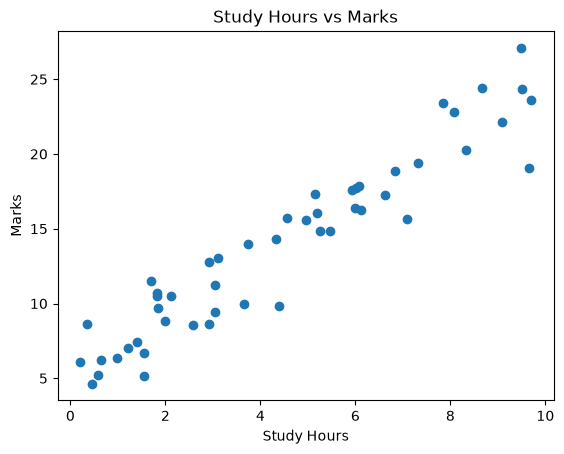

Slope (m): 1.9447378627984213
Intercept (b): 5.247342023154038

Linear Regression

MSE: 3.185218649865341
R2 Score: 0.8631494906196248


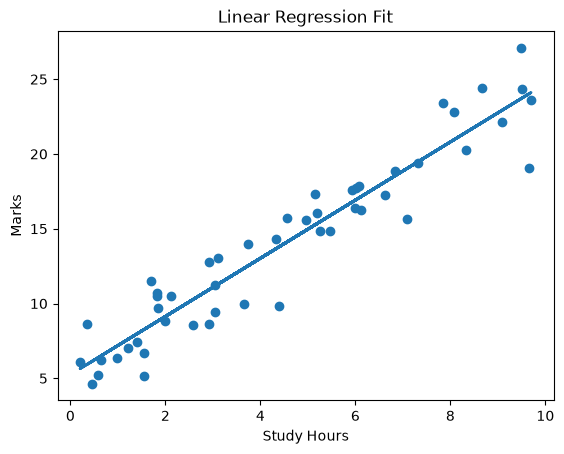


Ridge Regression

Ridge MSE: 3.1900312383743556


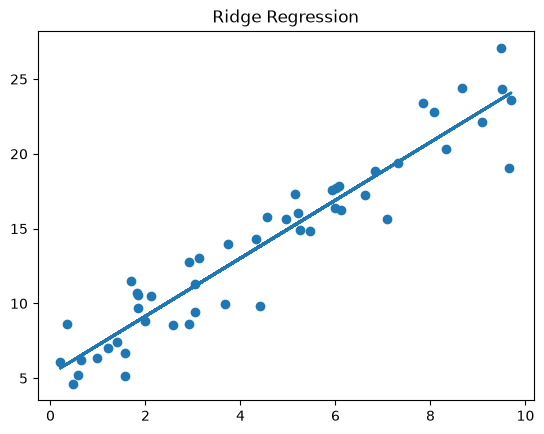


Lasso Regression

Lasso MSE: 3.2484944413372494


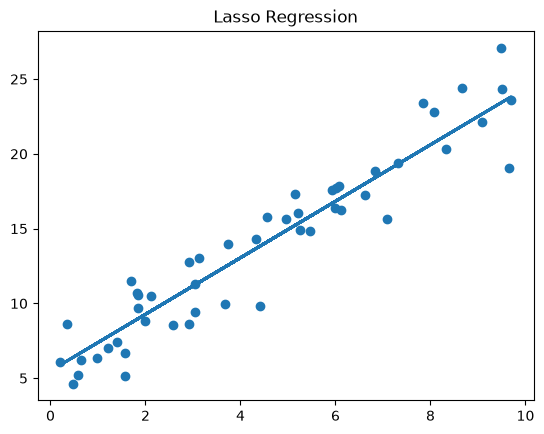


--- Coefficient Comparison ---
Linear: [[1.94473786]]
Ridge: [1.93935094]
Lasso: [1.88918397]

Predicted marks for 4 hours study: 13.03


In [16]:
# =========================================
#  1. Import libraries
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------------------
# 2. Create simple dataset (Study Hours vs Marks)
# -----------------------------------------
np.random.seed(42)
X = np.random.rand(50, 1) * 10   # study hours (0–10)
y = 5 + 2 * X + np.random.randn(50, 1) * 2  # marks with noise

# Convert to DataFrame
df = pd.DataFrame({
    'StudyHours': X.flatten(),
    'Marks': y.flatten()
})

print(df.head())

# -----------------------------------------
# 3. Visualize data
# -----------------------------------------
plt.scatter(df['StudyHours'], df['Marks'])
plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.title('Study Hours vs Marks')
plt.show()

# -----------------------------------------
# 4. Train-test split
# -----------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------------------
# 5. Linear Regression model
# -----------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Print coefficients
print("Slope (m):", model.coef_[0][0])
print("Intercept (b):", model.intercept_[0])

# -----------------------------------------
# 6. Evaluation
# -----------------------------------------
print("\n"+"="*30)
print("Linear Regression")
print("="*30+"\n")

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# -----------------------------------------
# 7. Plot regression line
# -----------------------------------------
plt.scatter(X, y)
plt.plot(X, model.predict(X), linewidth=2)
plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.title('Linear Regression Fit')
plt.show()




# -----------------------------------------
# 8. Ridge Regression
# -----------------------------------------
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print("\n"+"="*30)
print("Ridge Regression")
print("="*30+"\n")

print("Ridge MSE:", mean_squared_error(y_test, ridge_pred))

# Plot Ridge
plt.scatter(X, y)
plt.plot(X, ridge.predict(X), linewidth=2)
plt.title('Ridge Regression')
plt.show()



# -----------------------------------------
# 9. Lasso Regression
# -----------------------------------------
lasso = Lasso(alpha=0.5)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

print("\n"+"="*30)
print("Lasso Regression")
print("="*30+"\n")

print("Lasso MSE:", mean_squared_error(y_test, lasso_pred))
# Plot Lasso
plt.scatter(X, y)
plt.plot(X, lasso.predict(X), linewidth=2)
plt.title('Lasso Regression')
plt.show()



# -----------------------------------------
# 10. Compare Coefficien
# -----------------------------------------
print("\n--- Coefficient Comparison ---")
print("Linear:", model.coef_)
print("Ridge:", ridge.coef_)
print("Lasso:", lasso.coef_)

# -----------------------------------------
# 11. Simple Prediction Example
# -----------------------------------------
hours = np.array([[4]])
prediction = model.predict(hours)

print(f"\nPredicted marks for 4 hours study: {prediction[0][0]:.2f}")


# linear regression Maths

---

#### 1) Model (Line Equation)

For one feature:
$$
h(x) = wx + b
$$
For multiple features:
$$
h(x) = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b
$$
Compact (vector) form:
$$
h(x) = w^T x + b
$$

Where,
* h(x): prediction
* w: weights
* b: bias

---

#### 2) Loss Function (MSE)

We measure how wrong the predictions are.
$$
Loss = J(w,b) = \frac{1}{n} \sum_{i=1}^{n} (h(x_i) - y_i)^2
$$

$$ where, $$
$$ y_i: true value $$

$$ h(x_i): predicted value $$

$$ n: number of samples $$


👉 Goal: **minimize (J(w,b))**

---

#### 3) Gradient Descent (Optimization)

We update parameters to reduce error:
$$
w := w - \alpha \frac{\partial J}{\partial w}
$$

$$
b := b - \alpha \frac{\partial J}{\partial b}
$$


Where:
$$
(\alpha) = learning_rate
$$

Gradients:

$$
\frac{\partial J}{\partial w} = \frac{2}{n} \sum_{i=1}^{n} (h(x_i) - y_i)x_i
$$


$$
\frac{\partial J}{\partial b} = \frac{2}{n} \sum_{i=1}^{n} (h(x_i) - y_i)
$$


👉 Repeat updates until convergence.

---

#### 4) Regularization (Prevent Overfitting)

**L2 Regularization (Ridge)**

$$
J(w,b) = \frac{1}{n} \sum_{i=1}^{n} (h(x_i) - y_i)^2 + \lambda \sum_{j=1}^{n} w_j^2
$$


* Penalizes large weights
* Makes weights **small but not zero**

---

**L1 Regularization (Lasso)**
$$
J(w,b) = \frac{1}{n} \sum_{i=1}^{n} (h(x_i) - y_i)^2 + \lambda \sum_{j=1}^{n} |w_j|
$$


* Can push weights to **exactly zero**
* Useful for **feature selection**

---

#### Final Flow (Big Picture)

1. Model: h(x) = w^T x + b
2. Loss: MSE
3. Minimize loss using gradient descent
4. Add regularization (L1/L2) if needed

---


# Notation Confusion

---

#### The Core Idea (Same Everywhere)

Linear regression is just:

👉 **output = (something × input) + constant**

---

#### Single Variable (One Feature)

You might see:

* `y = mx + c`
* `y = mx + b`
* `y = wx + b`
* `y = θ₁x + θ₀`
* `h(x) = wx + b`

These are **all the same equation**, just different symbols.

#### Meaning of each part:

* `x` → input (feature)

* `y` → actual output (true value)

* `h(x)` → predicted output (model’s guess)

* `m`, `w`, `θ₁` → slope (how much y changes when x changes)

* `b`, `c`, `θ₀` → intercept (value when x = 0)

---

#### One Clean Version (Recommended)

To avoid confusion, you can stick with:

👉 `h(x) = wx + b`

Why?

* `h(x)` clearly means prediction
* `w` = weight (used in ML)
* `b` = bias (standard ML term)

---



#### Multiple Features (Important Jump)

When you have more input feautures:

```
y = w1x1 + w2x2 + w3x3 + b
```

#### explanation

Each feature must have its own input:

* `x1` → study hours
* `x2` → sleep
* `x3` → attendance

So:

👉 `h(x) = w1x1 + w2x2 + ... + wn*xn + b`

---

#### Compact Vector Form (Advanced but useful)

👉 `h(x) = wᵀx + b`

Don’t worry too much now, just know:

* it's the same thing, written shorter

---

#### Common Beginner Confusions (Cleared)

* `m`, `w`, `θ` → all mean **weight**
* `b`, `c`, `θ₀` → all mean **bias/intercept**
* `y` vs `h(x)`:

  * `y` = real value
  * `h(x)` = predicted value

---

#### Final Mental Model

Think:

👉 **Prediction = weighted sum of inputs + bias**

That’s it. Everything else is just notation style.

---
